# 16 - Windowed vs Carried vs Load-Gated Recursive Inference

## Research question

Does inference protocol change the apparent failure mode after training?

## Artifact paths loaded

- `results/v5/recursive_inference/recursive_policy_comparison.csv`
- `results/v5/recursive_inference/recursive_policy_results.json`
- `results/v5/figures/recursive_policy_temperature_breakdown.png`
- `results/v5/figures/cold_sequence_recursive_case_study.png`
- `results/v5/figures/hot_sequence_recursive_failure_case.png`

All cells are analysis-only. No heavy training is run.


In [1]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown, Image
except Exception:
    def display(x): print(x)
    def Markdown(x): return x
    def Image(filename=None, **kwargs): return f"Image({filename})"

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "legend.frameon": False,
    "figure.dpi": 140,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.18,
})
COLORS = ["#264653", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51", "#0072B2", "#56B4E9", "#8C8C8C"]
OUR_COLOR = "#E76F51"
BASELINE_COLOR = "#B0BEC5"

def find_repo_root():
    start = Path.cwd().resolve()
    for p in [start] + list(start.parents):
        if (p / "results" / "v5").exists() and (p / "reports" / "v5_campaign").exists():
            return p
    raise RuntimeError("Could not find repository root containing results/v5 and reports/v5_campaign")

ROOT = find_repo_root()
RESULTS = ROOT / "results" / "v5"
REPORTS = ROOT / "reports" / "v5_campaign"
FIGS = RESULTS / "figures"
missing_artifacts = []

def rel(path):
    path = Path(path)
    try:
        return str(path.relative_to(ROOT)).replace("\\", "/")
    except Exception:
        return str(path).replace("\\", "/")

def artifact(path):
    p = ROOT / path if isinstance(path, str) else Path(path)
    if not p.exists():
        missing_artifacts.append(rel(p))
    return p

def read_csv_safe(path):
    p = artifact(path)
    if not p.exists():
        display(Markdown(f"**Missing artifact:** `{rel(p)}`"))
        return pd.DataFrame()
    return pd.read_csv(p)

def read_json_safe(path):
    p = artifact(path)
    if not p.exists():
        display(Markdown(f"**Missing artifact:** `{rel(p)}`"))
        return {}
    with p.open("r", encoding="utf-8") as handle:
        return json.load(handle)

def show_artifact_status(paths):
    rows = []
    for item in paths:
        p = ROOT / item
        rows.append({"artifact": item, "exists": p.exists(), "bytes": p.stat().st_size if p.exists() else None})
        if not p.exists():
            missing_artifacts.append(item)
    display(pd.DataFrame(rows))

def show_missing():
    unique = sorted(set(missing_artifacts))
    if unique:
        display(Markdown("### Missing artifacts recorded by this notebook"))
        display(pd.DataFrame({"missing_artifact": unique}))
    else:
        display(Markdown("### Missing artifacts recorded by this notebook: none"))

def maybe_display_png(path):
    p = ROOT / path if isinstance(path, str) else Path(path)
    if p.exists():
        display(Image(filename=str(p)))
    else:
        missing_artifacts.append(rel(p))
        display(Markdown(f"Existing figure not found: `{rel(p)}`"))

print("Repository root:", ROOT)


Repository root: D:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC


In [2]:
ARTIFACTS = [
    'results/v5/recursive_inference/recursive_policy_comparison.csv',
    'results/v5/recursive_inference/recursive_policy_results.json',
    'results/v5/figures/recursive_policy_temperature_breakdown.png',
    'results/v5/figures/cold_sequence_recursive_case_study.png',
    'results/v5/figures/hot_sequence_recursive_failure_case.png',
]
show_artifact_status(ARTIFACTS)

policy = read_csv_safe("results/v5/recursive_inference/recursive_policy_comparison.csv")
policy_json = read_json_safe("results/v5/recursive_inference/recursive_policy_results.json")


,artifact,exists,bytes
0,results/v5/recursive_inference/recursive_polic...,True,947
1,results/v5/recursive_inference/recursive_polic...,True,158198
2,results/v5/figures/recursive_policy_temperatur...,True,43585
3,results/v5/figures/cold_sequence_recursive_cas...,True,43698
4,results/v5/figures/hot_sequence_recursive_fail...,True,47923


In [3]:
if not policy.empty:
    cols = ["policy","rmse_pct","maxe_pct","pvr_disch_eps0","delta_ratio_disch","reanchor_pct","chain_start_pct","rmse_n20degC","rmse_n10degC","rmse_40degC"]
    display(policy[cols].sort_values("rmse_pct").round(4))
    base = float(policy.loc[policy["policy"]=="windowed_independent","rmse_pct"].iloc[0])
    lg = float(policy.loc[policy["policy"]=="load_gated","rmse_pct"].iloc[0])
    display(Markdown(f"**Load-gated improvement:** {lg:.2f}% RMSE, {lg-base:+.2f} pp versus windowed independent."))


,policy,rmse_pct,maxe_pct,pvr_disch_eps0,delta_ratio_disch,reanchor_pct,chain_start_pct,rmse_n20degC,rmse_n10degC,rmse_40degC
3,load_gated,8.4090,27.9822,0.0,0.7511,11.24,0.28,9.9521,9.2068,5.3887
5,confidence_weighted_blend,9.6862,32.4548,0.0,0.7514,44.21,0.28,14.2987,8.7493,4.2168
2,temperature_gated,10.9822,29.6282,0.0,0.7514,32.68,0.28,11.1109,14.2859,4.2214
0,windowed_independent,11.0486,46.1873,0.0,0.7514,100.00,100.00,16.7544,9.6602,4.2214
6,hybrid_temperature_load_gate,11.1470,29.6282,0.0,0.7514,3.90,0.28,11.1109,14.2859,5.3887
4,rest_gated_reanchor,11.3160,29.6282,0.0,0.7514,3.58,0.28,11.1109,14.2859,6.3810
1,carried_anchor,11.7799,29.6282,0.0,0.7514,0.28,0.28,11.1109,14.2859,8.5837


**Load-gated improvement:** 8.41% RMSE, -2.64 pp versus windowed independent.

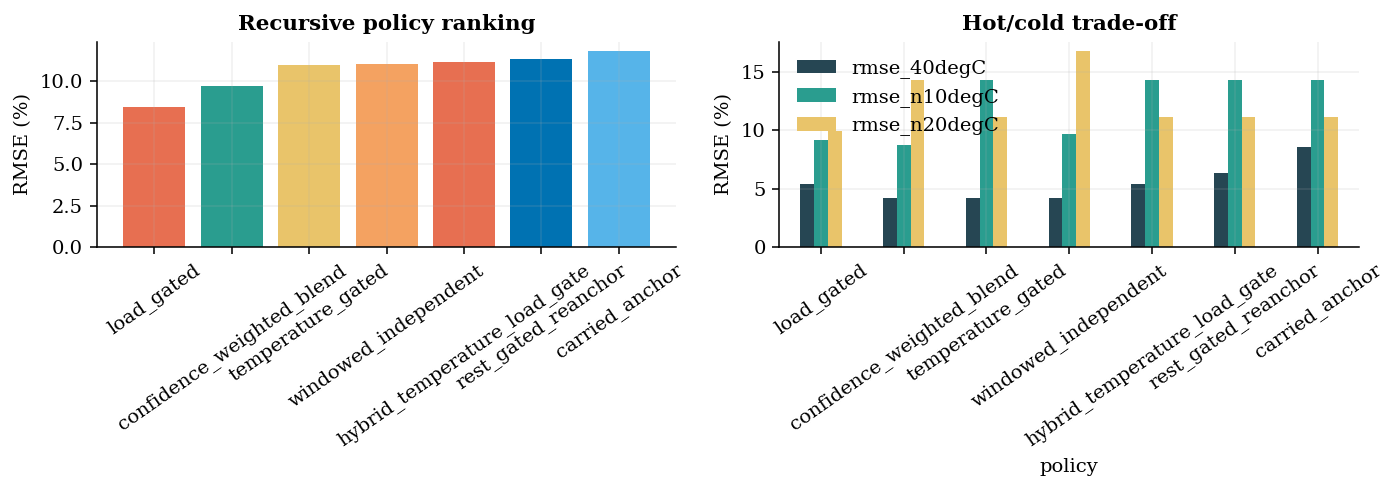

In [4]:
if not policy.empty:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
    order = policy.sort_values("rmse_pct")["policy"]
    axes[0].bar(order, policy.set_index("policy").loc[order, "rmse_pct"], color=[OUR_COLOR if p=="load_gated" else COLORS[i % len(COLORS)] for i, p in enumerate(order)])
    axes[0].set_ylabel("RMSE (%)"); axes[0].set_title("Recursive policy ranking"); axes[0].tick_params(axis="x", rotation=35)
    policy.set_index("policy").loc[order, ["rmse_40degC","rmse_n10degC","rmse_n20degC"]].plot(kind="bar", ax=axes[1], color=COLORS[:3])
    axes[1].set_ylabel("RMSE (%)"); axes[1].set_title("Hot/cold trade-off"); axes[1].tick_params(axis="x", rotation=35)
    plt.tight_layout(); plt.show()


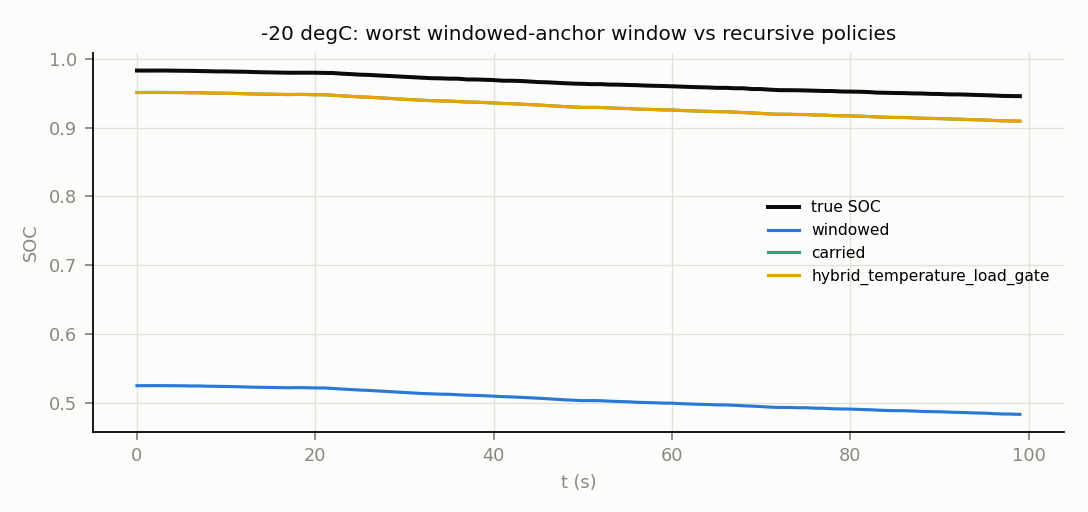

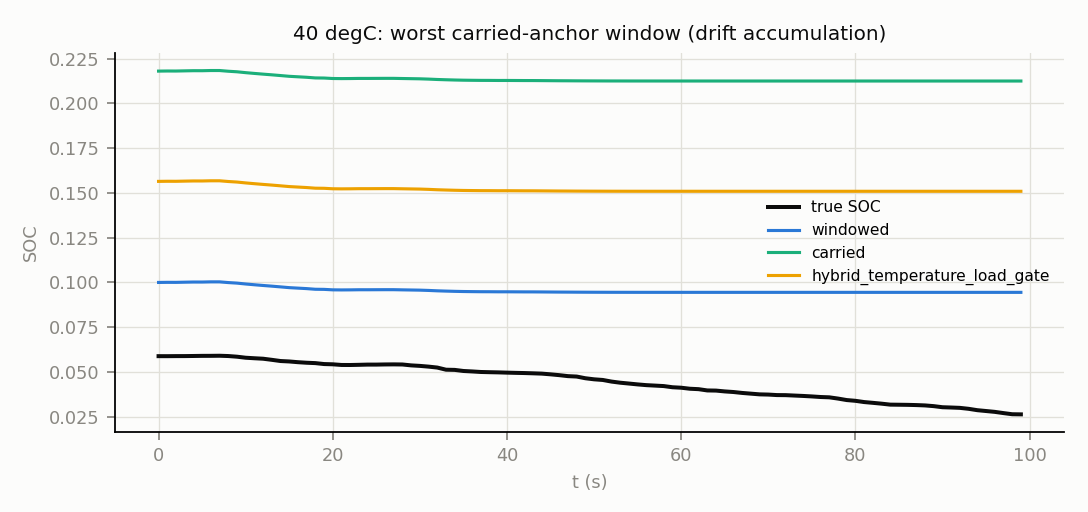

In [5]:
maybe_display_png("results/v5/figures/cold_sequence_recursive_case_study.png")
maybe_display_png("results/v5/figures/hot_sequence_recursive_failure_case.png")


## Interpretation

Independent windowing repeatedly reinitializes the anchor, manufacturing cold-starts. Load-gated recursive inference reduces this artifact by carrying anchors through reliable chains and re-anchoring under appropriate rest/load conditions.

## Reviewer-risk note

Do not frame all gating as positive. The v5 positive result is specifically load-gated recursive inference on corrected data.

## Final conclusion

Independent windowing manufactures repeated cold-starts; gated recursive inference reduces this artifact.


In [6]:
show_missing()


### Missing artifacts recorded by this notebook: none

## Publication asset export (PUBLICATION_ASSET_EXPORT_V1)

This cell exports manuscript-ready figures/tables from existing v5 CSV/JSON artifacts only. It does not run training or alter experiment results.


In [7]:
# PUBLICATION_ASSET_EXPORT_V1
from pathlib import Path
import sys
EXPORT_DIR = Path('notebooks/ablation_studies_v5_final').resolve()
if str(EXPORT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPORT_DIR))
from publication_asset_exports import export_for_notebook
validation = export_for_notebook('16')
print('publication assets refreshed:', validation['png_present'], 'figures and', validation['csv_present'], 'tables')


publication assets refreshed: 7 figures and 7 tables
